# Getting Started with metaheuristic‑designer

We’ll minimise the `Sphere` function with a Genetic Algorithm (GA).
The library is imported as `mhd`; concrete components come from subpackages,
base classes and factory functions from the top‑level.

In [1]:
import numpy as np
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Sphere

## 1. Define the objective function

`Sphere` in 5 dimensions, minimisation mode.

In [2]:
DIM = 5
objfunc = Sphere(DIM, mode="min")

## 2. Reproducible random seed

In [3]:
rng = mhd.check_random_state(42)

## 3. Assemble the GA strategy

- Uniform initializer between -10 and 10, population size 50.
- Gaussian mutation (one component, std=0.01).
- Uniform crossover.
- Parent selection: best 25 individuals.
- Survivor selection: elitism, keeping 5 best parents.
- Crossover/mutation probabilities: 0.8 / 0.2.

In [4]:
strategy = mhd.strategies.GA(
    initializer=mhd.initializers.UniformInitializer(DIM, -10, 10, pop_size=50, random_state=rng),
    mutation_op=mhd.operators.create_operator("mutation.gaussian_mutation", N=1, F=0.01, random_state=rng),
    cross_op=mhd.operators.create_operator("crossover.uniform", random_state=rng),
    parent_sel=mhd.parent_selection_methods.create_parent_selection("best", amount=25, random_state=rng),
    survivor_sel=mhd.survivor_selection_methods.create_survivor_selection("elitism", amount=5, random_state=rng),
    mutation_prob=0.2,
    crossover_prob=0.8,
    random_state=rng,
)

## 4. Run the algorithm

Stop after 100 generations (`stop_cond="ngen"`).

In [7]:
algo = mhd.algorithms.StandardAlgorithm(
    objfunc, strategy,
    ngen=100, stop_cond="ngen", verbose=True, v_timer=-1, # -1 forces every generation to show progress
)
population = algo.optimize()

Initializing optimization of Sphere function using GA
-----------------------------------------------------

Optimizing Sphere function using GA:
	Real time Spent: 0.001 s
	CPU time Spent:  0.001 s
	Generation: 0
	Best fitness: 30.00415672709608
	Evaluations of fitness: 50


Optimizing Sphere function using GA:
	Real time Spent: 0.003 s
	CPU time Spent:  0.003 s
	Generation: 1
	Best fitness: 29.920225762490936
	Evaluations of fitness: 100


Optimizing Sphere function using GA:
	Real time Spent: 0.005 s
	CPU time Spent:  0.005 s
	Generation: 2
	Best fitness: 12.555924483242388
	Evaluations of fitness: 150


Optimizing Sphere function using GA:
	Real time Spent: 0.006 s
	CPU time Spent:  0.006 s
	Generation: 3
	Best fitness: 12.555924483242388
	Evaluations of fitness: 200


Optimizing Sphere function using GA:
	Real time Spent: 0.007 s
	CPU time Spent:  0.007 s
	Generation: 4
	Best fitness: 2.515819298239742
	Evaluations of fitness: 250


Optimizing Sphere function using GA:
	Real time S

## 5. Inspect the result

Best solution: [ 0.11260857 -0.05032314  0.46733495 -0.01772043  0.43243467]
Best fitness: 0.42092882496340256
Number of generations: 100
Real time spent: 0.10319s
CPU time spent: 0.10321s
Number of fitness evaluations: 5050
Best fitness: 0.42092882496340256


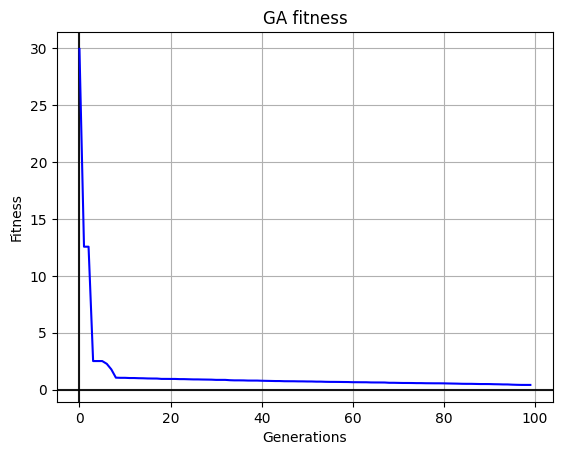

In [8]:
solution, fitness = population.best_solution()
print(f"Best solution: {solution}")
print(f"Best fitness: {fitness}")
algo.display_report(show_plots=True)